# 11-13 合併：新手統計與 A/B 測試入門

這份練習適合**第一次接觸統計分析與 A/B 測試**的學習者。重點是看懂概念、執行程式並解讀結果，不要求推導公式。

## 學完後，你可以

1. 用 Bootstrap 粗略估計平均數的 95% 信賴區間。
2. 比較 A、B 兩組轉換率，並初步解讀 p 值。
3. 理解 MDE、檢定力與所需樣本數之間的關係。
4. 將樣本數換算成大約需要執行幾天。


## 課程地圖

1. **抽樣與信賴區間**：一個平均數有多不確定？
2. **A/B 測試入門**：兩組轉換率看起來真的不同嗎？
3. **實驗規劃**：開始實驗前，大約需要多少資料？


## 0. 載入套件與資料

本練習使用：

- `sessions`：每列是一個網站工作階段。
- `events`：每列是一個使用者事件。

下面的程式會自動尋找專案中的資料夾。


In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

from pathlib import Path

data_path = Path.cwd() / "data"

print("data 資料夾內容：")
for p in data_path.iterdir():
    print(p)
# 不論從專案根目錄或 output/jupyter-notebook 開啟，都嘗試找到資料。
from pathlib import Path

data_candidates = [
    Path.cwd() / "data" / "raw",
    Path.cwd() / "data",
]

data_dir = None

for path in data_candidates:
    if path.exists():
        data_dir = path
        print(f"找到資料夾：{data_dir}")
        break

if data_dir is None:
    raise FileNotFoundError("找不到 data 資料夾")
data_dir = next((path for path in data_candidates if path.exists()), None)
if data_dir is None:
    raise FileNotFoundError("找不到 code/data/raw，請從本專案資料夾開啟 Notebook。")

sessions = pd.read_csv(data_dir / "sessions.csv")
events = pd.read_csv(data_dir / "events.csv")

print(f"sessions：{len(sessions):,} 列")
print(f"events：{len(events):,} 列")
display(sessions.head(3))


data 資料夾內容：
c:\Users\student\Downloads\20260806_data-main\20260806_data-main\20260730_code\data\.mplconfig
c:\Users\student\Downloads\20260806_data-main\20260806_data-main\20260730_code\data\outputs
c:\Users\student\Downloads\20260806_data-main\20260806_data-main\20260730_code\data\raw
找到資料夾：c:\Users\student\Downloads\20260806_data-main\20260806_data-main\20260730_code\data\raw
sessions：70,000 列
events：232,067 列


,session_id,customer_id,session_start,device,traffic_source,campaign,experiment_group
0,1,2473,2025-08-14T11:02,desktop,sem,none,B
1,2,2155,2024-02-29T11:56,mobile,sem,retarget,A
2,3,2437,2024-11-13T16:23,mobile,sem,none,B


# 單元一：抽樣與 95% 信賴區間

母體通常很大，我們常只能取得其中一部分，也就是**樣本**。不同樣本算出的平均數會略有差異，因此最好不要只報一個平均數，也要說明它的不確定範圍。

先用一小組模擬訂單金額練習。設定亂數種子後，每次執行都會得到相同資料。


In [15]:
rng = np.random.default_rng(42)
order_amount = pd.Series(
    rng.gamma(shape=2, scale=500, size=120),
    name="order_amount",
)

print(f"訂單數：{len(order_amount)}")
print(f"平均訂單金額：{order_amount.mean():.2f}")
display(order_amount.describe().round(2).to_frame())


訂單數：120
平均訂單金額：925.11


,order_amount
count,120.00
mean,925.11
std,640.09
min,73.72
25%,476.91
50%,826.28
75%,1199.17
max,3743.50


## 1.1 Bootstrap 的簡單想法

Bootstrap 會從現有樣本中**放回抽樣**，重複計算很多次平均數。這些平均數的中間 95% 可作為一個實用的不確定範圍。

先不用背公式，只要記住四步：抽、算、重複、取中間 95%。


樣本平均數：925.11
Bootstrap 95% 信賴區間：808.56 ～ 1041.41


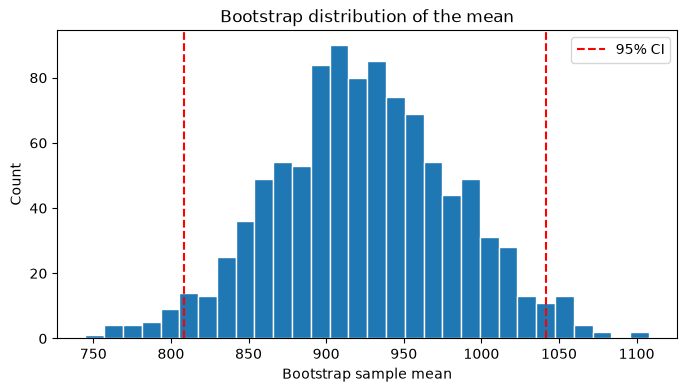

In [16]:
bootstrap_means = []

for _ in range(1000):
    resample = order_amount.sample(
        n=len(order_amount), replace=True, random_state=rng
    )
    bootstrap_means.append(resample.mean())

ci_low, ci_high = np.percentile(bootstrap_means, [2.5, 97.5])

print(f"樣本平均數：{order_amount.mean():.2f}")
print(f"Bootstrap 95% 信賴區間：{ci_low:.2f} ～ {ci_high:.2f}")

plt.figure(figsize=(8, 4))
plt.hist(bootstrap_means, bins=30, edgecolor="white")
plt.axvline(ci_low, color="red", linestyle="--", label="95% CI")
plt.axvline(ci_high, color="red", linestyle="--")
plt.xlabel("Bootstrap sample mean")
plt.ylabel("Count")
plt.title("Bootstrap distribution of the mean")
plt.legend()
plt.show()


### 如何解讀？

信賴區間越窄，通常代表平均數估計越穩定。初學時可將它理解為「合理估計範圍」，但不要說成「母體平均數有 95% 機率在這個已算出的區間內」。

### 練習 1

把 Bootstrap 次數從 `1000` 改成 `300`，觀察區間是否完全相同。


In [17]:
# TODO：修改 repeat_count，再重新執行。
repeat_count = 300
practice_means = []

practice_rng = np.random.default_rng(7)
for _ in range(repeat_count):
    sample = order_amount.sample(
        n=len(order_amount), replace=True, random_state=practice_rng
    )
    practice_means.append(sample.mean())

practice_ci = np.percentile(practice_means, [2.5, 97.5])
print(f"重複 {repeat_count} 次的區間：{practice_ci[0]:.2f} ～ {practice_ci[1]:.2f}")


重複 300 次的區間：818.29 ～ 1045.69


**提示／參考想法：**結果通常不會完全相同，因為 Bootstrap 含有隨機抽樣。重複次數較多時，結果通常會比較穩定，但不保證區間一定更窄。


# 單元二：A/B 測試入門

A/B 測試把流量隨機分到兩個版本，再比較結果。本單元只看最常見的指標：**轉換率**。

分析單位是工作階段，所以要讓一列代表一個 `session_id`。只要該工作階段曾出現 `purchase`，就標記為已轉換（1），否則為 0。


In [18]:
purchase_session_ids = set(
    events.loc[events["event_type"] == "purchase", "session_id"]
)

experiment = sessions[["session_id", "experiment_group"]].copy()
experiment["converted"] = (
    experiment["session_id"].isin(purchase_session_ids).astype(int)
)

display(experiment.head())
print("每個 session_id 是否只出現一次：", experiment["session_id"].is_unique)


,session_id,experiment_group,converted
0,1,B,0
1,2,A,0
2,3,B,0
3,4,B,0
4,5,A,0


每個 session_id 是否只出現一次： True


## 2.1 比較 A、B 組轉換率

`converted` 只有 0 和 1，所以它的平均數就是轉換率。


In [19]:
ab_summary = (
    experiment.groupby("experiment_group", as_index=False)
    .agg(
        sessions=("session_id", "count"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean"),
    )
)
ab_summary["conversion_rate_pct"] = ab_summary["conversion_rate"] * 100
display(ab_summary.round(3))

rate_a = ab_summary.set_index("experiment_group").loc["A", "conversion_rate"]
rate_b = ab_summary.set_index("experiment_group").loc["B", "conversion_rate"]
lift_pp = (rate_b - rate_a) * 100
print(f"B - A 的絕對差異：{lift_pp:.2f} 個百分點")


,experiment_group,sessions,conversions,conversion_rate,conversion_rate_pct
0,A,34459,4162,0.121,12.078
1,B,35541,4491,0.126,12.636


B - A 的絕對差異：0.56 個百分點


## 2.2 用 p 值做初步判斷

只看轉換率高低可能受到抽樣波動影響。兩比例 z 檢定的虛無假設是「A、B 真實轉換率相同」。

初學時先使用這個判讀規則：

- `p < 0.05`：有較強證據認為兩組不同。
- `p >= 0.05`：目前證據不足，**不代表兩組一定完全相同**。


In [20]:
summary = ab_summary.set_index("experiment_group")
x_a, n_a = summary.loc["A", ["conversions", "sessions"]]
x_b, n_b = summary.loc["B", ["conversions", "sessions"]]

pooled_rate = (x_a + x_b) / (n_a + n_b)
standard_error = np.sqrt(
    pooled_rate * (1 - pooled_rate) * (1 / n_a + 1 / n_b)
)
z_score = (x_b / n_b - x_a / n_a) / standard_error
p_value = 2 * stats.norm.sf(abs(z_score))

print(f"z 值：{z_score:.3f}")
print(f"p 值：{p_value:.4f}")
if p_value < 0.05:
    print("結論：兩組轉換率有統計上的差異證據。")
else:
    print("結論：目前沒有足夠證據認為兩組轉換率不同。")


z 值：2.242
p 值：0.0249
結論：兩組轉換率有統計上的差異證據。


### 練習 2

完成下面的判斷文字：除了 p 值，也要看差異的方向與大小。請執行後，嘗試用一句自己的話說明結果。


In [21]:
# TODO：先猜結果，再執行確認。
higher_group = "B" if rate_b > rate_a else "A"
print(f"轉換率較高的是 {higher_group} 組。")
print(f"差異大小為 {abs(lift_pp):.2f} 個百分點。")
print(f"p 值為 {p_value:.4f}。")


轉換率較高的是 B 組。
差異大小為 0.56 個百分點。
p 值為 0.0249。


**參考句型：**「B 組比 A 組高／低約 X 個百分點；p 值為 Y，因此目前有／沒有足夠的差異證據。」

> p 值小不等於差異一定有商業價值；還要考慮提升幅度、成本與風險。


# 單元三：開始前先規劃樣本數

如果資料太少，即使真的有差異，也可能偵測不到。樣本數規劃常用四個概念：

- **基準轉換率**：目前版本大約有多少人轉換。
- **MDE**：我們希望偵測到的最小差異；此處使用絕對差異。
- **alpha**：常用 0.05。
- **power（檢定力）**：常用 0.80；越高通常需要越多樣本。

下面提供教學用的近似函式；本課只需會使用和解讀，不需背公式。


In [22]:
def required_sample_per_group(p1, mde, alpha=0.05, power=0.80):
    # 估計 50/50 分流時，每組約需多少樣本。
    p2 = p1 + mde
    if not (0 < p1 < 1 and 0 < p2 < 1):
        raise ValueError("轉換率必須介於 0 和 1 之間。")

    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_power = stats.norm.ppf(power)
    numerator = (z_alpha + z_power) ** 2 * (
        p1 * (1 - p1) + p2 * (1 - p2)
    )
    return int(np.ceil(numerator / mde**2))


baseline_rate = experiment["converted"].mean()
mde = 0.01       # 1 個百分點
n_per_group = required_sample_per_group(baseline_rate, mde)

print(f"基準轉換率：{baseline_rate:.2%}")
print(f"希望偵測的最小差異：{mde:.2%}")
print(f"每組約需：{n_per_group:,} 個工作階段")
print(f"兩組合計約需：{2 * n_per_group:,} 個工作階段")


基準轉換率：12.36%
希望偵測的最小差異：1.00%
每組約需：17,589 個工作階段
兩組合計約需：35,178 個工作階段


## 3.1 MDE 越小，樣本通常越多

想偵測很小的改變，就需要更多資料。以下只比較三種簡單情境。


In [23]:
mde_options = [0.005, 0.010, 0.020]
planning_table = pd.DataFrame({
    "MDE（百分點）": [value * 100 for value in mde_options],
    "每組樣本數": [
        required_sample_per_group(baseline_rate, value)
        for value in mde_options
    ],
})
display(planning_table)


,MDE（百分點）,每組樣本數
0,0.5,69198
1,1.0,17589
2,2.0,4540


## 3.2 把樣本數換成實驗天數

若每天約有 2,000 個工作階段可進入實驗，所需天數可用「總樣本數 ÷ 每日流量」粗估。實務上也要涵蓋完整星期，避免只觀察到特定幾天。


In [24]:
daily_traffic = 2000
total_required = 2 * n_per_group
estimated_days = int(np.ceil(total_required / daily_traffic))

print(f"每日可用流量：{daily_traffic:,}")
print(f"粗估需要：{estimated_days} 天")
print("提醒：正式實驗通常還要考慮完整週期、資料遺失與流量波動。")


每日可用流量：2,000
粗估需要：18 天
提醒：正式實驗通常還要考慮完整週期、資料遺失與流量波動。


### 練習 3

假設每日只有 1,000 個工作階段，並希望偵測 2 個百分點的差異。請修改下面兩個數字，算出新的每組樣本數與天數。


In [25]:
# TODO：可修改這兩個設定。
practice_mde = 0.02
practice_daily_traffic = 1000

practice_n = required_sample_per_group(baseline_rate, practice_mde)
practice_days = int(np.ceil(2 * practice_n / practice_daily_traffic))

print(f"每組樣本數：{practice_n:,}")
print(f"總樣本數：{2 * practice_n:,}")
print(f"粗估天數：{practice_days} 天")


每組樣本數：4,540
總樣本數：9,080
粗估天數：10 天


**提示／參考想法：**將 MDE 從 1 個百分點改成 2 個百分點後，需要的樣本會明顯減少；每日可用流量減少，則實驗天數會增加。


# 重點整理

- 樣本平均數會波動；Bootstrap 可用來估計合理範圍。
- A/B 測試要先確認分析單位，避免同一工作階段重複計數。
- 同時報告轉換率、差異大小與 p 值，不要只看其中一項。
- `p >= 0.05` 是證據不足，不是證明兩組完全一樣。
- MDE 越小、要求的檢定力越高，通常需要越多樣本。
- 樣本數規劃應在實驗開始前完成。

## 常見錯誤

1. Bootstrap 忘記使用放回抽樣（`replace=True`）。
2. 把 10% 到 12% 說成增加 2%；較清楚的說法是增加 **2 個百分點**。
3. 實驗進行中看到暫時顯著就立刻停止。
4. 只依統計顯著決定上線，忽略成本、風險與實際提升幅度。

## 選做延伸

試著將 MDE 改成 `0.005`、`0.01`、`0.02`，用一句話描述樣本數如何改變。完成後，你已具備閱讀更深入統計教材的基礎。
